In [1]:
# imports
from src.data_loader import load_data
from src.preprocess import prepare_data
from src.ML.train_svm import train_SVM
from src.ML.train_rf import train_random_forest
from src.ML.train_NN_improved import train_model as train_nn, TextClassifier, DeepTextClassifier, to_tensor, FocalLoss
from src.LM.lm_slovakBERT import train_model as train_model, evaluate_model, create_dataloaders, get_class_weights
from sklearn.metrics import classification_report
from src.plotting import plot_confusion_matrix, plot_learning_curve, plot_metrics_bar_chart
from src.benchmarking import training_benchmark, inference_benchmark, count_parameters, build_comparison_table, predict_fn

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = '/home/xkubanova_126831/bakalarka/nbs_binary/data/ekosentiment_titles_binary.csv'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at gerulata/slovakbert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using device: cuda


In [2]:
# Plotting results

def plot_results(class_to_idx, preds, labels, train_losses, test_accs, prefix='nn_'):
    idx_to_class = {i: cls for cls, i in class_to_idx.items()}
    target_names = [str(idx_to_class[i]) for i in sorted(idx_to_class.keys())]

    # CLASSIFICATION REPORT
   
    print("\nClassification Report:")
    print(classification_report(labels, preds, target_names=target_names, digits=4))

    idx_to_class = {i: cls for cls, i in class_to_idx.items()}
    target_names = [str(idx_to_class[i]) for i in sorted(idx_to_class.keys())]

    plot_confusion_matrix(labels, preds, target_names, prefix=prefix)
    plot_learning_curve(len(train_losses), train_losses, test_accs, prefix=prefix)
    plot_metrics_bar_chart(labels, preds, target_names, prefix=prefix)

In [3]:
# load data
df = load_data(DATA_PATH)
print(f'Dataset size: {df.shape}')
print(df.iloc[:, -1].value_counts())  # class distribution

Dataset shape: (694, 2)

Categories samples:

0:
  Príjmy vedúcich policajných funkcionárov A verejnosť tak mohla o celkových príjmoch policajnej elity u nás iba špekulovať. Jeho príjem za vlaňajšok v celkovej výške takmer 44-tisíc eur totiž prekonal viceprezident polície Ľubomír Ábel. Príjmy vedúcich policajných funkcionárov...

1:
  Analytik o osobných bankrotoch: Ich pravidlá sú podľa neho nastavené veľmi voľne "Obávam sa, že toto nastavenie bude do budúcnosti motivovať časť ľudí, aby sa nadmerne zadlžovala a následne využila osobný bankrot a začala bez dlhov. "Od štátu by som čakal také nastavenie legislatívy, ktoré ľudí navedie k právnemu a finančnému poradenstvu a riešeniu dlhov v rannej fáze problému. Búlik z OVB je pres...
Dataset size: (694, 2)
Text
Mladá žena je vodičkou autobusu: Tie najhrubšie komentáre, ktoré som si kedy vypočula! Autobusári sú ľudia, ktorí nás prevážajú z bodu A do bodu B a nielenže musia fungovať v rušnej premávke, ale tiež musia zaistiť bezpečnosť všetk

Category
0    0.727666
1    0.272334
Name: proportion, dtype: float64
using devide: cuda
Loading pretrained MiniLM model 'sentence-transformers/all-MiniLM-L6-v2' from Hugging Face…
Minilm embedder loaded on device: cuda
Loaded embedding cache.
Saved cache with 1386 entries.
Embeddings created. Shape: (555, 384)
Categories:
 Category
0    0.727928
1    0.272072
Name: proportion, dtype: float64

SUPPORT VECTOR MACHINE (SVM)

--- SVM Model Input Data Summary ---
X_train Shape (samples, features): (555, 384)
X_train Data Type: float64
y_train Shape (labels): (555,)
y_train Data Type: int64
Feature Vector Length (input_dim): 384
Matrix Format: <class 'numpy.ndarray'>
------------------------------
First sample (first 10 embedding values):
[-0.0981397   0.12419126 -0.32490024  0.06120977 -0.34975445  0.0631097
  0.27390516 -0.24072687  0.10196473 -0.18389593]
------------------------------

Computed class weights:
  0: 0.6869
  1: 1.8377

Best C found via StratifiedKFold: 0.01

--- SVM CLASS

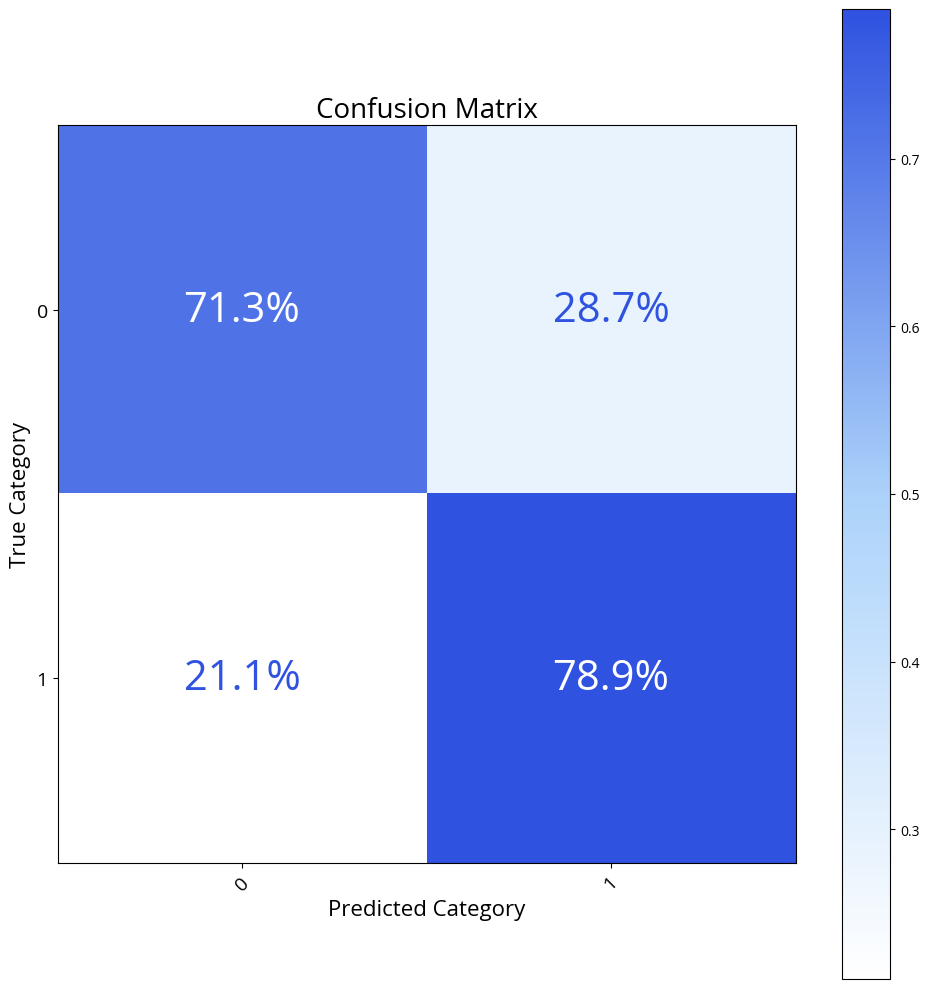

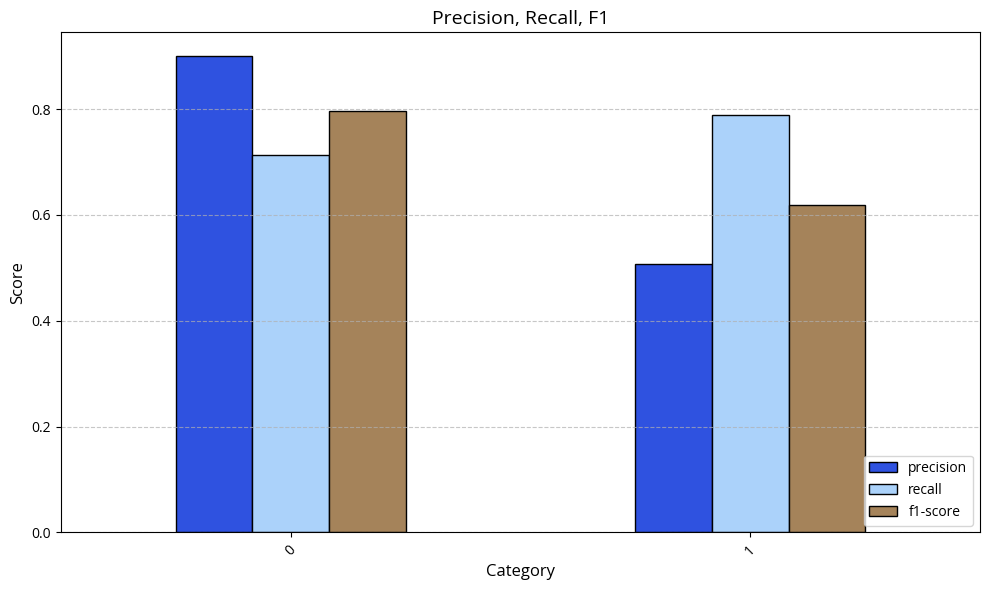

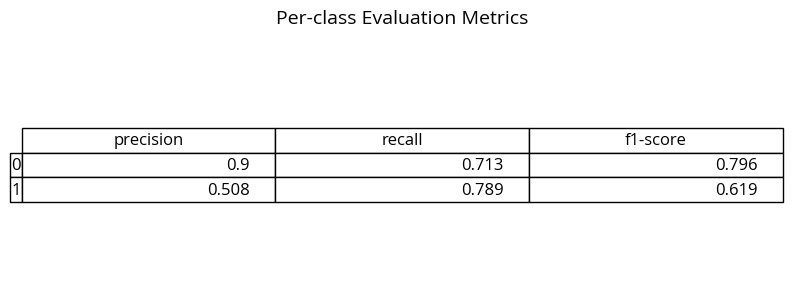


Training stats: {'training_time_s': 5.37, 'peak_ram_gb': 1.18, 'peak_gpu_gb': 0.55}
Inference stats: {'inference_time_s': 0.0001, 'per_sample_ms': 0.0008, 'latency_ms': 0.0737}


In [4]:
#SVM - MiniLM
from src.LM.embeddings.embedder_preprocess import load_minilm_embedder, prepare_data_minilm_simple
from src.ML.train_svm import train_SVM


print(df["Category"].value_counts(normalize=True))

# MiniLM embedder
device = "cuda" if torch.cuda.is_available() else "cpu"
print('using devide:', device)
tokenizer, minilm_model = load_minilm_embedder("sentence-transformers/all-MiniLM-L6-v2", device=device)

minilm_model.eval()  

X_train_vec, X_test_vec, y_train, y_test = prepare_data_minilm_simple(df, tokenizer, minilm_model, device=device)

print("Embeddings created. Shape:", X_train_vec.shape)
print("Categories:\n", y_train.value_counts(normalize=True))

target_names = [str(t) for t in sorted(y_train.unique())]

#svm_model = train_SVM(X_train_vec, y_train, X_test_vec, y_test, target_names, boost_factor = 3.0)


(svm_model, svm_preds, svm_true), svm_train_stats = training_benchmark(
    lambda: train_SVM(X_train_vec, y_train, X_test_vec, y_test, target_names, boost_factor = 1.0)
)

_, svm_inf_stats = inference_benchmark(
    lambda X: svm_model.predict(X), X_test_vec
)

print('\nTraining stats:', svm_train_stats)
print('Inference stats:', svm_inf_stats)

Category
0    0.727666
1    0.272334
Name: proportion, dtype: float64
using devide: cuda
Loading pretrained MiniLM model 'sentence-transformers/all-MiniLM-L6-v2' from Hugging Face…
Minilm embedder loaded on device: cuda
Loaded embedding cache.
Saved cache with 1386 entries.
Embeddings created. Shape: (555, 384)
Categories:
 Category
0    0.727928
1    0.272072
Name: proportion, dtype: float64

RANDOM FOREST

--- RF Model Input Data Summary ---
X_train Shape (samples, features): (555, 384)
X_train Data Type: float64
y_train Shape (labels): (555,)
y_train Data Type: int64
Feature Vector Length (input_dim): 384
Matrix Format: <class 'numpy.ndarray'>
------------------------------
First sample (first 10 embedding values):
Prvá vzorka (prvých 10 TF-IDF hodnôt):
[-0.0981397   0.12419126 -0.32490024  0.06120977 -0.34975445  0.0631097
  0.27390516 -0.24072687  0.10196473 -0.18389593]
------------------------------
Original class weights: [0.68688119 1.83774834]
Boosted class weights: [0.686881

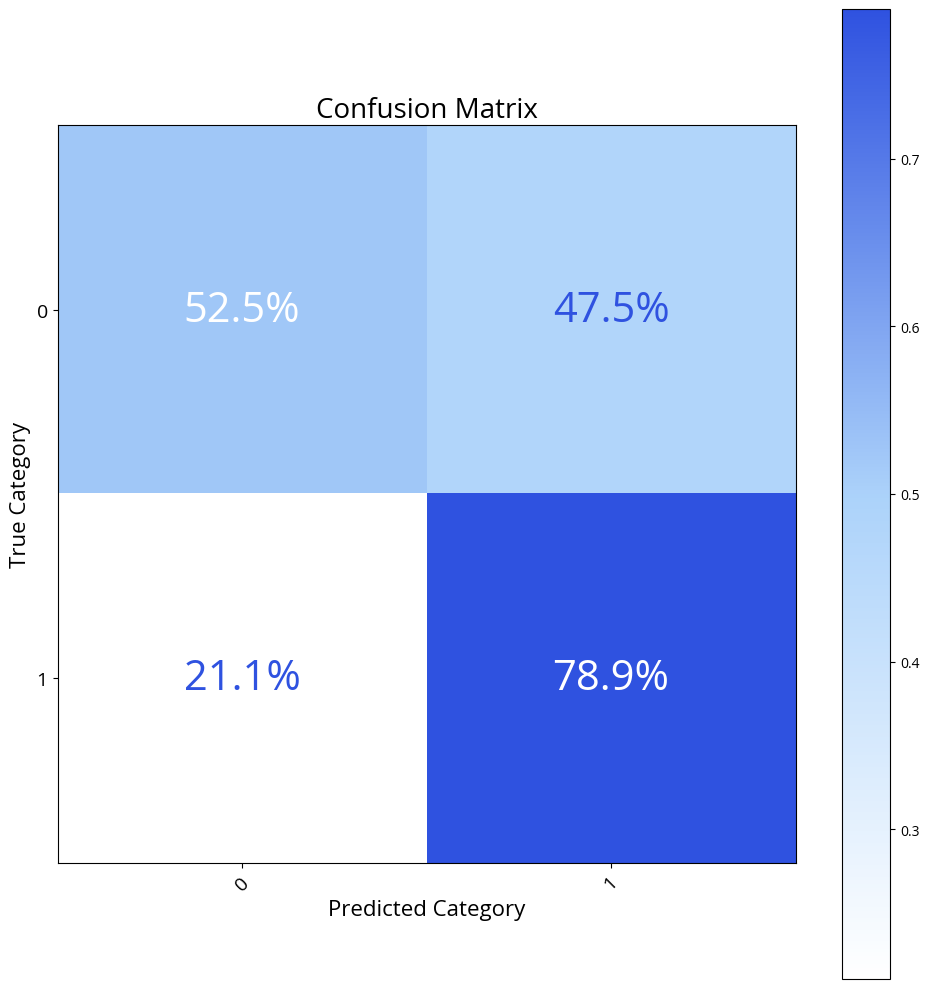

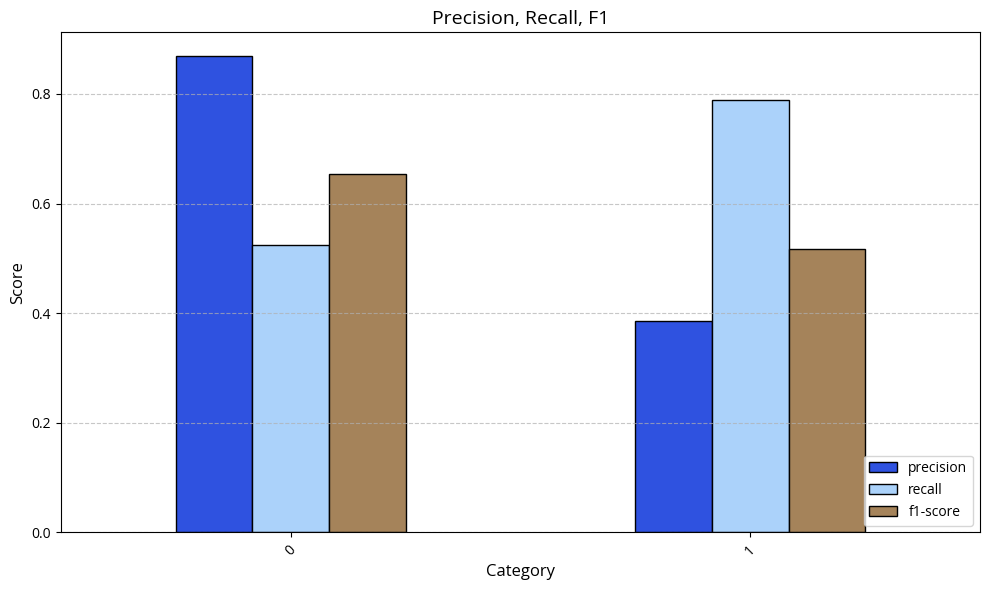

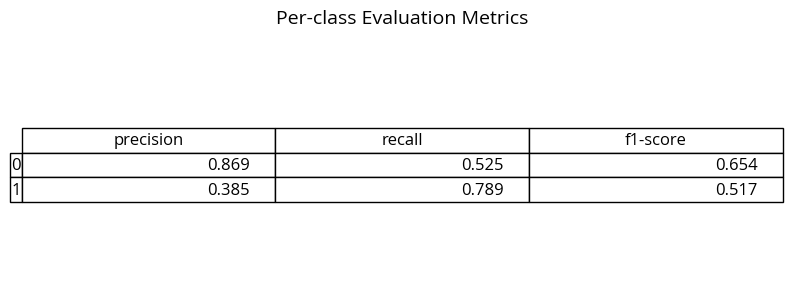


Training stats: {'training_time_s': 13.33, 'peak_ram_gb': 1.17, 'peak_gpu_gb': 0.55}
Inference stats: {'inference_time_s': 0.0158, 'per_sample_ms': 0.1135, 'latency_ms': 17.1993}


In [5]:
from src.LM.embeddings.embedder_preprocess import load_minilm_embedder, prepare_data_minilm_simple
# Random Forest - MiniLM

print(df["Category"].value_counts(normalize=True))

# MiniLM embedder
device = "cuda" if torch.cuda.is_available() else "cpu"
print('using devide:', device)
tokenizer, minilm_model = load_minilm_embedder("sentence-transformers/all-MiniLM-L6-v2", device=device)

minilm_model.eval()  


X_train_vec, X_test_vec, y_train, y_test = prepare_data_minilm_simple(df, tokenizer, minilm_model, device=device)

print("Embeddings created. Shape:", X_train_vec.shape)
print("Categories:\n", y_train.value_counts(normalize=True))

target_names = [str(t) for t in sorted(y_train.unique())]

#rf_model = train_random_forest(X_train_vec, y_train, X_test_vec, y_test, target_names, boost_factor = 2.1)

(rf_model, rf_preds, rf_true), rf_train_stats = training_benchmark(
    lambda: train_random_forest(X_train_vec, y_train, X_test_vec, y_test, target_names, boost_factor = 1.0)
)

_, rf_inf_stats = inference_benchmark(
    lambda X: rf_model.predict(X), X_test_vec
)

print('\nTraining stats:', rf_train_stats)
print('Inference stats:', rf_inf_stats)

using devide: cuda
Loading pretrained MiniLM model 'sentence-transformers/all-MiniLM-L6-v2' from Hugging Face…
Minilm embedder loaded on device: cuda
Loaded embedding cache.
Saved cache with 1386 entries.
Input dimension: 384


/home/xkubanova_126831/bakalarka/nbs_binary/src/ML/train_NN_improved.py:85: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('alpha', torch.tensor(alpha, dtype=torch.float32))



Classification Report:
              precision    recall  f1-score   support

           0     0.8161    0.7030    0.7553       101
           1     0.4231    0.5789    0.4889        38

    accuracy                         0.6691       139
   macro avg     0.6196    0.6410    0.6221       139
weighted avg     0.7086    0.6691    0.6825       139



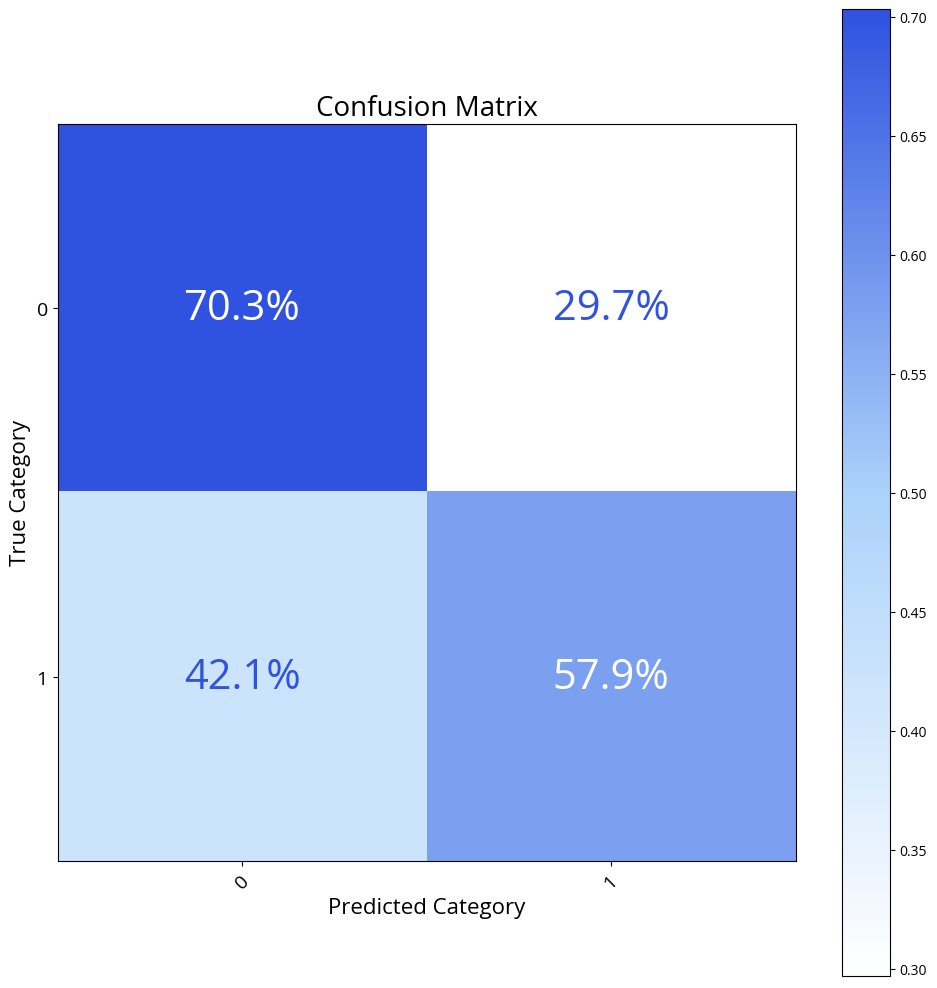

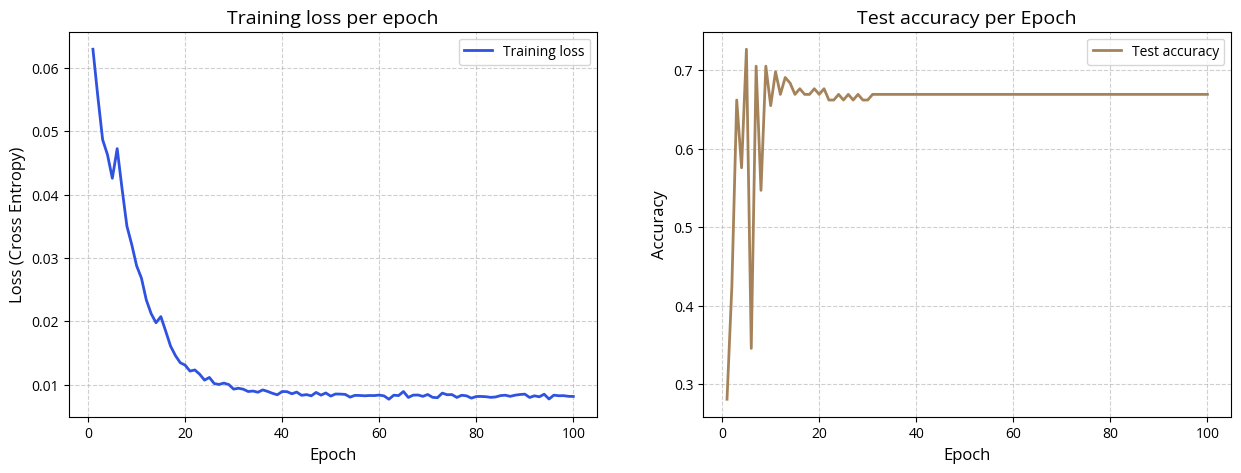

<Figure size 640x480 with 0 Axes>

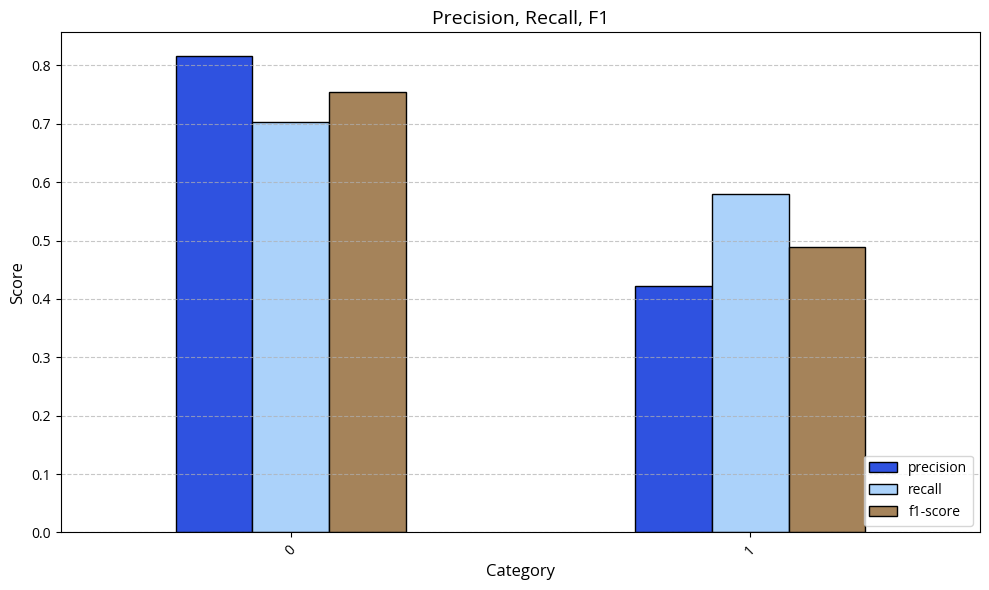

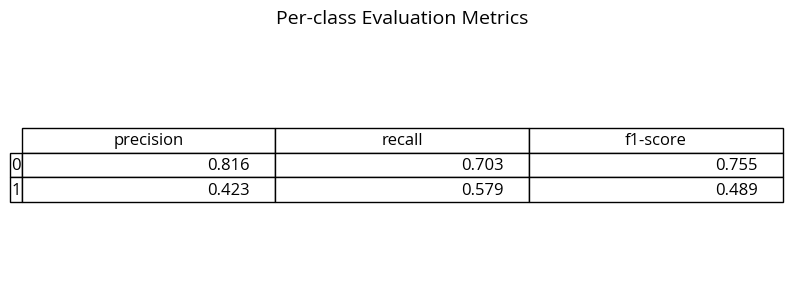


Training stats: {'training_time_s': 2.53, 'peak_ram_gb': 1.42, 'peak_gpu_gb': 0.57}
Inference stats: {'inference_time_s': 0.0002, 'per_sample_ms': 0.0015, 'latency_ms': 0.2196}
Parameters: 99074


In [6]:
# Simple NN - MiniLM
device = "cuda"
print('using devide:', device)
tokenizer, minilm_model = load_minilm_embedder("sentence-transformers/all-MiniLM-L6-v2", device=device)
minilm_model.eval()  

X_train, X_test, y_train, y_test = prepare_data_minilm_simple(df, tokenizer, minilm_model, device=device)


alpha = torch.tensor([1.0, 5.0])

nn_result, simple_nn_train_stats = training_benchmark(
    lambda: train_nn(
        X_train, y_train, X_test, y_test,
        model_class=TextClassifier,
        model_params={'hidden_dim': 256},
        epochs=100,
        lr=1e-3,
        loss_fn=FocalLoss(alpha=alpha, gamma=4.5),
        use_scheduler=True
    )
)

simple_nn, class_to_idx, nn_preds, nn_true, nn_losses, nn_accs = nn_result
plot_results(class_to_idx, nn_preds, nn_true, nn_losses, nn_accs, prefix='nn_')

X_test_t = to_tensor(X_test).to(device)
simple_nn.eval()
_, simple_nn_inf_stats = inference_benchmark(
    lambda X: simple_nn(X).argmax(dim=1).cpu().numpy(), X_test_t
)

_, simple_nn_trainable_params = count_parameters(simple_nn)


print('\nTraining stats:', simple_nn_train_stats)
print('Inference stats:', simple_nn_inf_stats)
print('Parameters:', simple_nn_trainable_params)



Loaded embedding cache.
Saved cache with 1386 entries.
Input dimension: 384


/home/xkubanova_126831/bakalarka/nbs_binary/src/ML/train_NN_improved.py:85: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('alpha', torch.tensor(alpha, dtype=torch.float32))



Classification Report:
              precision    recall  f1-score   support

           0     0.8506    0.7327    0.7872       101
           1     0.4808    0.6579    0.5556        38

    accuracy                         0.7122       139
   macro avg     0.6657    0.6953    0.6714       139
weighted avg     0.7495    0.7122    0.7239       139



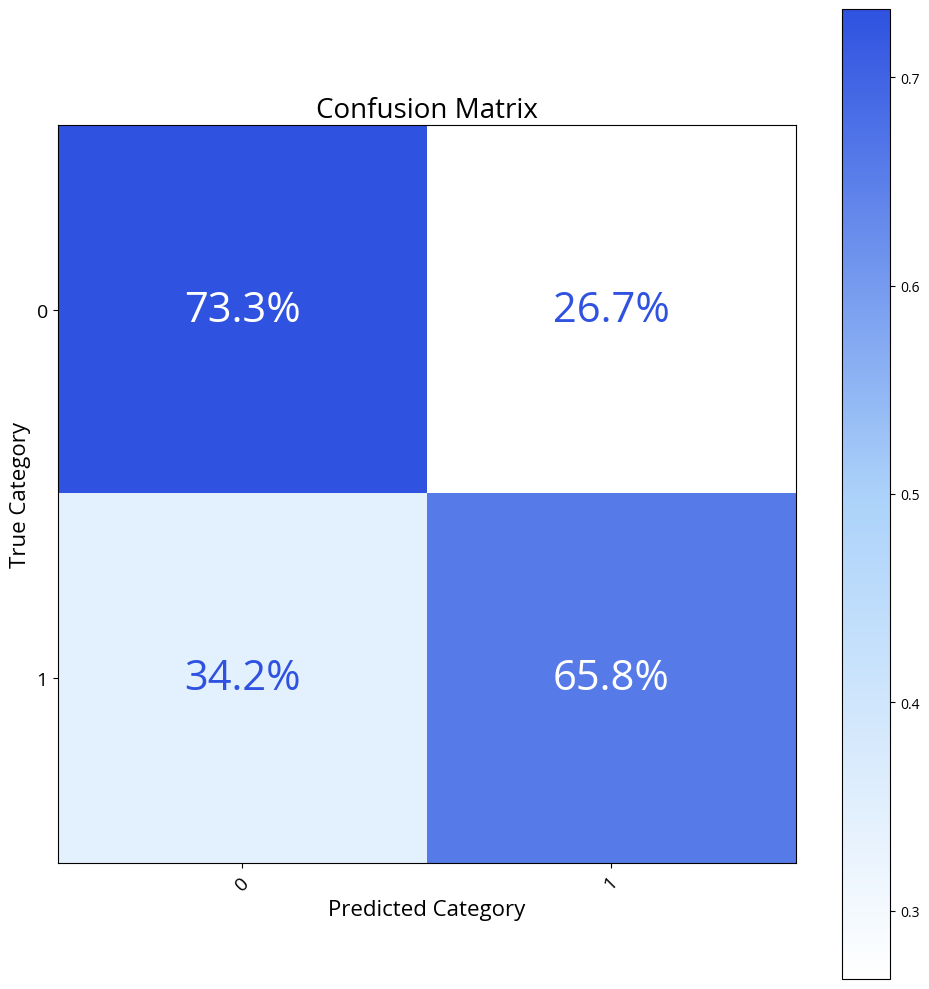

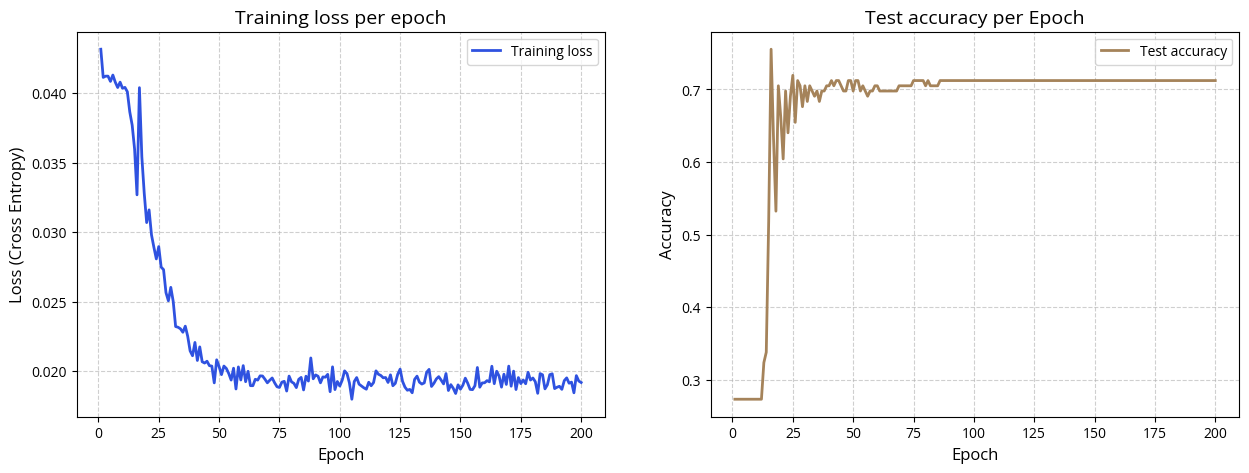

<Figure size 640x480 with 0 Axes>

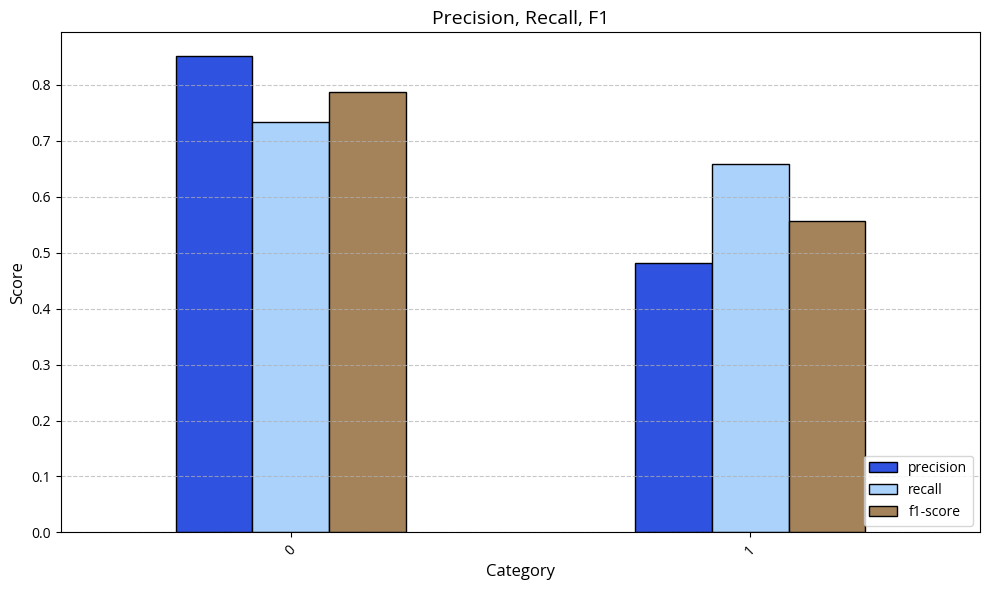

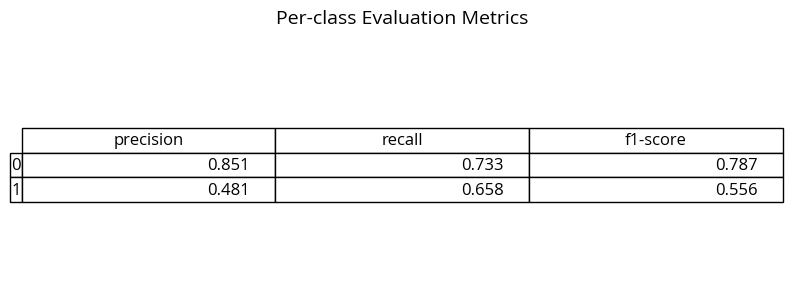


Training stats: {'training_time_s': 7.3, 'peak_ram_gb': 1.48, 'peak_gpu_gb': 0.57}
Inference stats: {'inference_time_s': 0.0005, 'per_sample_ms': 0.0036, 'latency_ms': 0.3286}
Parameters: 142474


In [7]:
# Deep NN - MiniLM

X_train, X_test, y_train, y_test = prepare_data_minilm_simple(df, tokenizer, minilm_model, device=device)

alpha = torch.tensor([1, 4.5])

nn_result, deep_nn_train_stats = training_benchmark(
    lambda: train_nn(
        X_train, y_train, X_test, y_test,
        model_class=DeepTextClassifier,
        model_params={'hidden_dims': [256, 128, 64, 32, 16, 8]},
        epochs=200,
        lr=1e-3,
        loss_fn=FocalLoss(alpha=alpha, gamma=5),
        use_scheduler=True
    )
)

deep_nn, class_to_idx, deep_preds, deep_true, deep_losses, deep_accs = nn_result
plot_results(class_to_idx, deep_preds, deep_true, deep_losses, deep_accs, prefix='deep_')

X_test_t = to_tensor(X_test).to(device)
deep_nn.eval()
_, deep_nn_inf_stats = inference_benchmark(
    lambda X: deep_nn(X).argmax(dim=1).cpu().numpy(), X_test_t
)

_, deep_nn_trainable_params = count_parameters(deep_nn)

print('\nTraining stats:', deep_nn_train_stats)
print('Inference stats:', deep_nn_inf_stats)
print('Parameters:', deep_nn_trainable_params)


Dataset shape: (694, 2)

Categories samples:

0:
  Príjmy vedúcich policajných funkcionárov A verejnosť tak mohla o celkových príjmoch policajnej elity u nás iba špekulovať. Jeho príjem za vlaňajšok v celkovej výške takmer 44-tisíc eur totiž prekonal viceprezident polície Ľubomír Ábel. Príjmy vedúcich policajných funkcionárov...

1:
  Analytik o osobných bankrotoch: Ich pravidlá sú podľa neho nastavené veľmi voľne "Obávam sa, že toto nastavenie bude do budúcnosti motivovať časť ľudí, aby sa nadmerne zadlžovala a následne využila osobný bankrot a začala bez dlhov. "Od štátu by som čakal také nastavenie legislatívy, ktoré ľudí navedie k právnemu a finančnému poradenstvu a riešeniu dlhov v rannej fáze problému. Búlik z OVB je pres...
Target names: [0, 1]
Label distribution:
Category_encoded
0    505
1    189
Name: count, dtype: int64
Train size: 555
Test size: 139


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at gerulata/slovakbert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/5, Loss: 0.1368
Epoch 2/5, Loss: 0.1025
Epoch 3/5, Loss: 0.0691
Epoch 4/5, Loss: 0.0524
Epoch 5/5, Loss: 0.0338
Best threshold (F1-optimal): 0.800
Best F1 score: 0.756| Precision: 0.705 | Recall: 0.816

Recall-optimal threshold: 0.440
F1: 0.661 | Precision: 0.500 | Recall: 0.974
              precision    recall  f1-score   support

           0       0.98      0.63      0.77       101
           1       0.50      0.97      0.66        38

    accuracy                           0.73       139
   macro avg       0.74      0.80      0.72       139
weighted avg       0.85      0.73      0.74       139



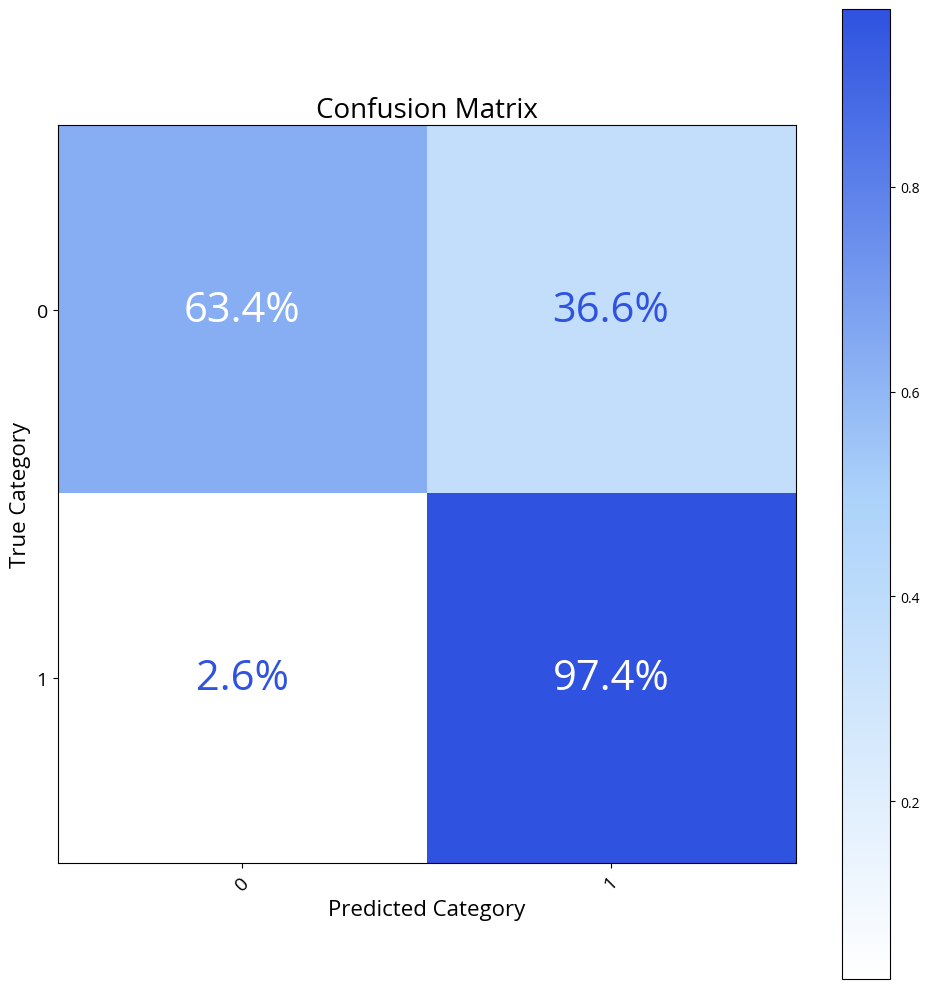

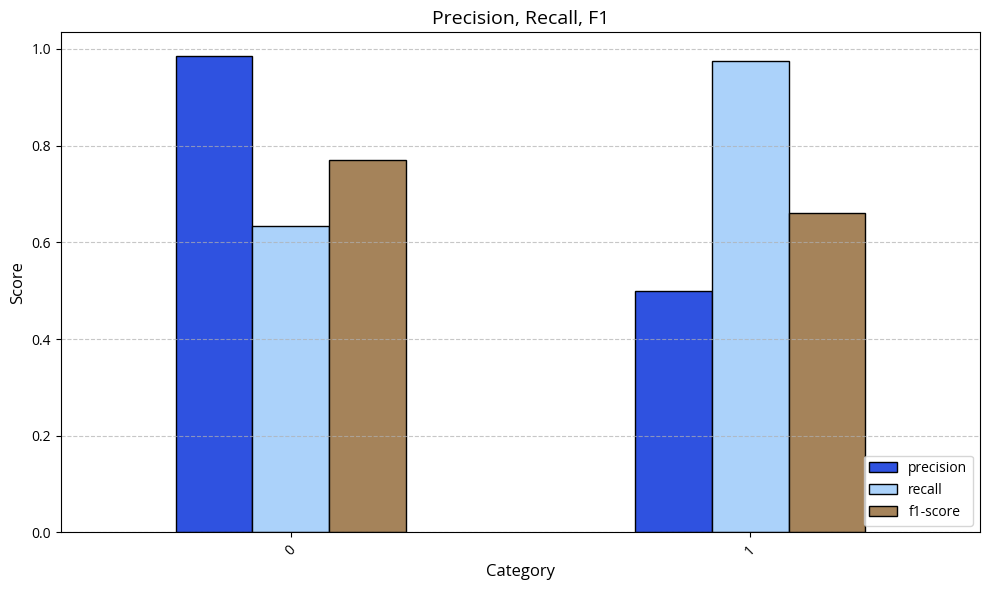

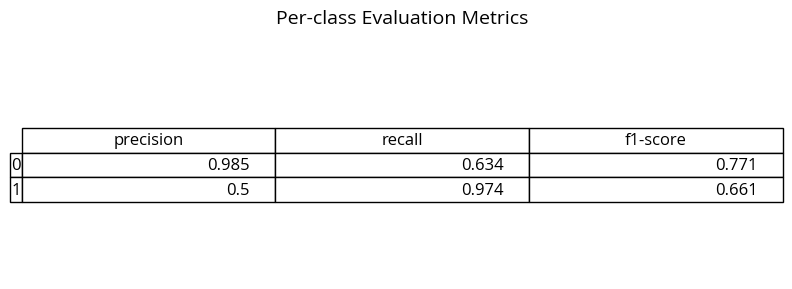

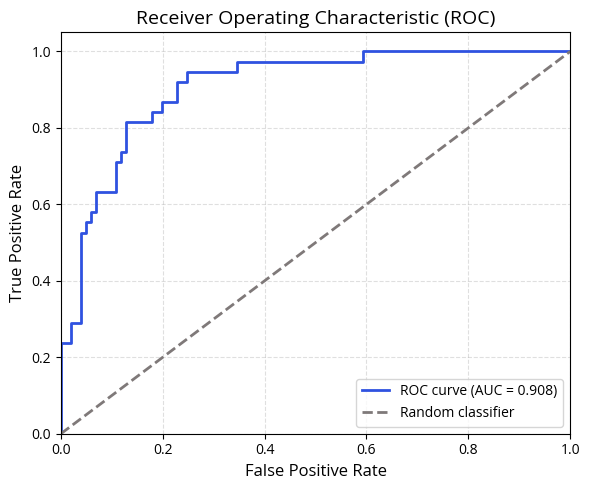

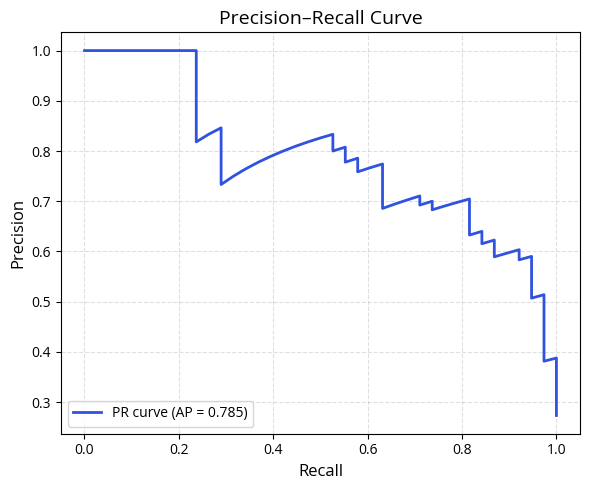


Training stats: {'training_time_s': 15.42, 'peak_ram_gb': 1.6, 'peak_gpu_gb': 4.87}
Inference stats: {'inference_time_s': 0.4962, 'per_sample_ms': 3.5699, 'latency_ms': 5.8966}
Parameters: 124646402


In [8]:
# SlovakBERT
from sklearn.calibration import LabelEncoder
from sklearn.calibration import LabelEncoder
from sklearn.model_selection import train_test_split
from transformers import AutoModelForSequenceClassification
from src.preprocess import clean_text
from src.LM.lm_slovakBERT import model as bert_model, tokenizer
from src.LM.lm_slovakBERT import train_model as train_bert, evaluate_model, create_dataloaders, get_class_weights


#Load data
df = load_data("/home/xkubanova_126831/bakalarka/nbs_binary/data/ekosentiment_titles_binary.csv")
df['Text'] = df['Text'].apply(clean_text)  

le = LabelEncoder()
df['Category_encoded'] = le.fit_transform(df['Category'])


target_names = le.classes_.tolist()

print("Target names:", target_names)
print("Label distribution:")
print(df["Category_encoded"].value_counts())


X_train_text, X_test_text, y_train_encoded, y_test_encoded = train_test_split(
    df['Text'].tolist(), 
    df['Category_encoded'].tolist(),
    test_size=0.2, 
    random_state=42,
    stratify=df['Category_encoded']
)
print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))

train_loader, test_loader = create_dataloaders(X_train_text, y_train_encoded, X_test_text, y_test_encoded)
class_weights = get_class_weights(y_train_encoded, device)



def init_fresh_bert():
    fresh_model = AutoModelForSequenceClassification.from_pretrained(
        "gerulata/slovakbert",
        num_labels=2
    ).to(device)
    for name, param in fresh_model.named_parameters():
        if name.startswith("bert.embeddings") or name.startswith("bert.encoder.layer.0"):
            param.requires_grad = False
    return fresh_model

bert_result, bert_train_stats = training_benchmark(
    lambda: train_bert(
        init_fresh_bert(), train_loader,
        epochs=5,
        lr=2e-5,
        use_focal_loss=True,
        class_weights=class_weights
    )
)
bert_trained = bert_result

_, bert_inf_stats = inference_benchmark(
    lambda X: predict_fn(bert_trained, X, tokenizer, device),
    X_test_text
)
evaluate_model(bert_trained, test_loader, label_names=target_names)

_, bert_trainable_params = count_parameters(bert_trained)

print('\nTraining stats:', bert_train_stats)
print('Inference stats:', bert_inf_stats)
print('Parameters:', bert_trainable_params)

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Dataset shape: (694, 2)

Categories samples:

0:
  Príjmy vedúcich policajných funkcionárov A verejnosť tak mohla o celkových príjmoch policajnej elity u nás iba špekulovať. Jeho príjem za vlaňajšok v celkovej výške takmer 44-tisíc eur totiž prekonal viceprezident polície Ľubomír Ábel. Príjmy vedúcich policajných funkcionárov...

1:
  Analytik o osobných bankrotoch: Ich pravidlá sú podľa neho nastavené veľmi voľne "Obávam sa, že toto nastavenie bude do budúcnosti motivovať časť ľudí, aby sa nadmerne zadlžovala a následne využila osobný bankrot a začala bez dlhov. "Od štátu by som čakal také nastavenie legislatívy, ktoré ľudí navedie k právnemu a finančnému poradenstvu a riešeniu dlhov v rannej fáze problému. Búlik z OVB je pres...
Target names: [0, 1]
Label distribution:
Category_encoded
0    505
1    189
Name: count, dtype: int64
Train size: 555
Test size: 139


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/7, Loss: 0.2120
Epoch 2/7, Loss: 0.1573
Epoch 3/7, Loss: 0.1349
Epoch 4/7, Loss: 0.1099
Epoch 5/7, Loss: 0.1166
Epoch 6/7, Loss: 0.0956
Epoch 7/7, Loss: 0.0565
Best threshold (F1-optimal): 0.690
Best F1 score: 0.745

Recall-optimal threshold: 0.496
F1: 0.661 | Precision: 0.500 | Recall: 0.974
              precision    recall  f1-score   support

           0       0.98      0.63      0.77       101
           1       0.50      0.97      0.66        38

    accuracy                           0.73       139
   macro avg       0.74      0.80      0.72       139
weighted avg       0.85      0.73      0.74       139



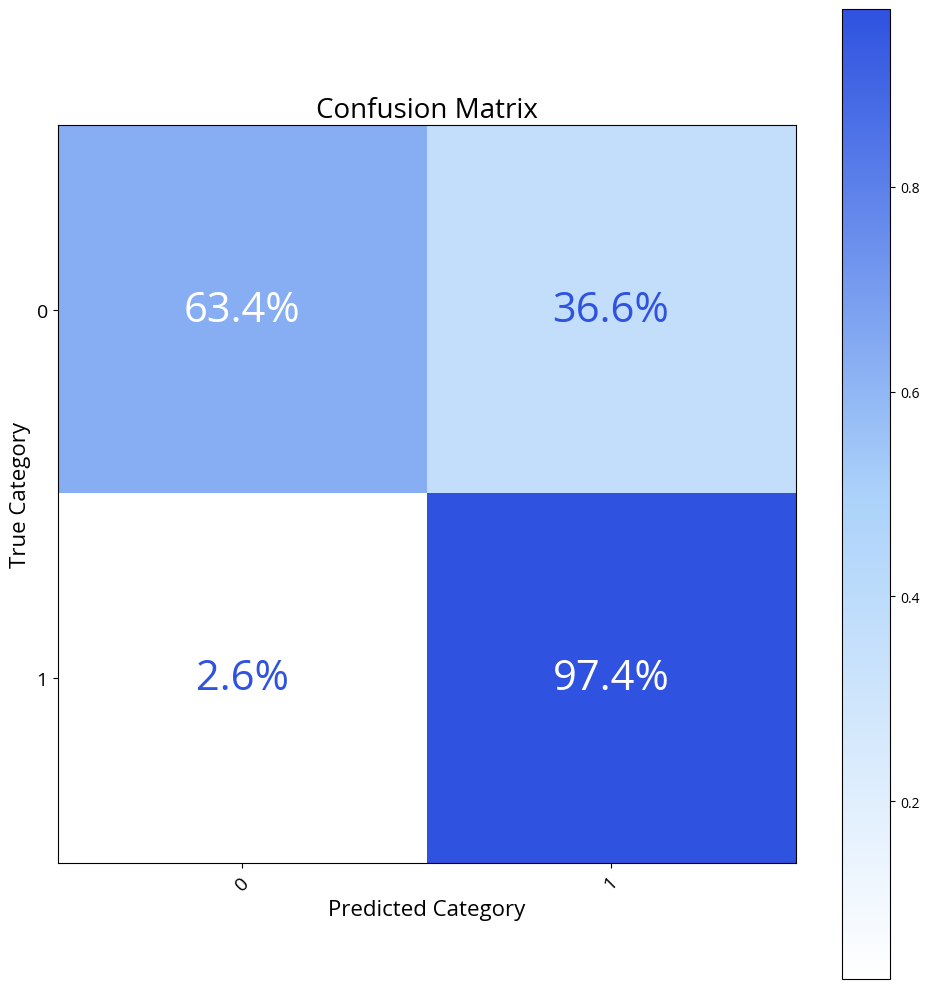

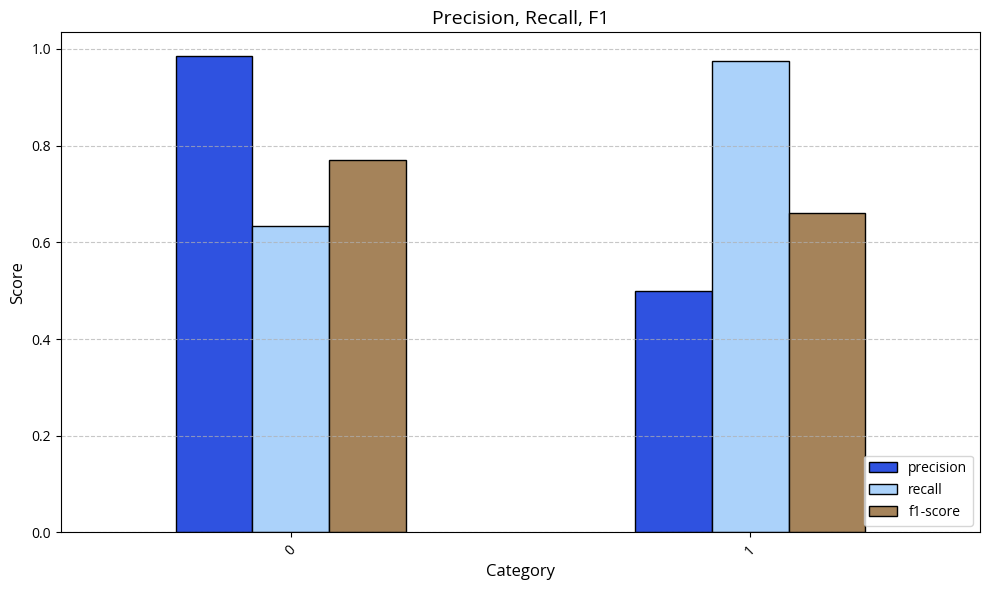

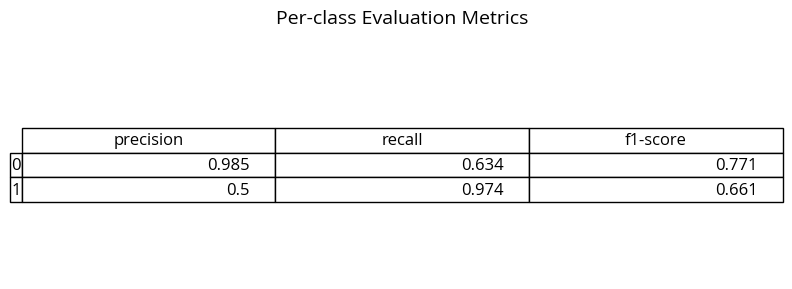

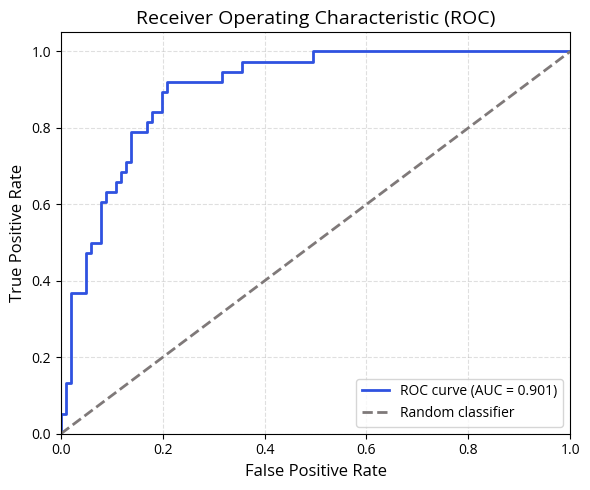

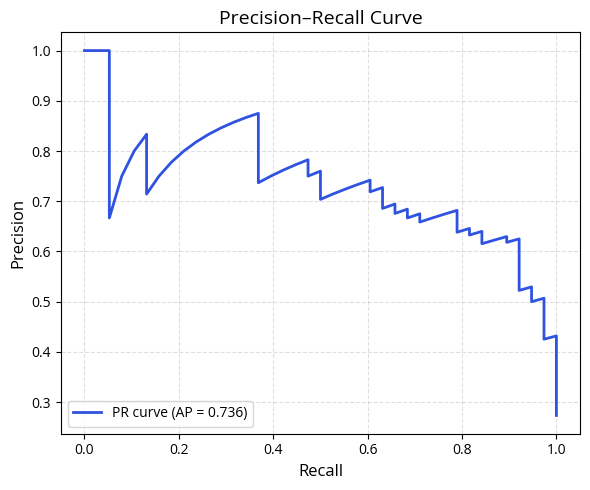


Training stats: {'training_time_s': 27.39, 'peak_ram_gb': 2.82, 'peak_gpu_gb': 9.62}
Inference stats: {'inference_time_s': 0.3971, 'per_sample_ms': 2.8566, 'latency_ms': 5.3339}
Parameters: 278045186


In [9]:
# Roberta XML 
from sklearn.calibration import LabelEncoder
from sklearn.calibration import LabelEncoder
from sklearn.model_selection import train_test_split
from transformers import AutoModelForSequenceClassification
from src.preprocess import clean_text
from src.LM.lm_roberta_xml import model as roberta_model, tokenizer
from src.LM.lm_roberta_xml import train_model as train_roberta, evaluate_model, create_dataloaders, get_class_weights



df = load_data("/home/xkubanova_126831/bakalarka/nbs_binary/data/ekosentiment_titles_binary.csv")
df['Text'] = df['Text'].apply(clean_text)  

le = LabelEncoder()
df['Category_encoded'] = le.fit_transform(df['Category'])

target_names = le.classes_.tolist()

print("Target names:", target_names)
print("Label distribution:")
print(df["Category_encoded"].value_counts())


X_train_text, X_test_text, y_train_encoded, y_test_encoded = train_test_split(
    df['Text'].tolist(), 
    df['Category_encoded'].tolist(),
    test_size=0.2, 
    random_state=42,
    stratify=df['Category_encoded']
)
print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))

train_loader, test_loader = create_dataloaders(X_train_text, y_train_encoded, X_test_text, y_test_encoded)
class_weights = get_class_weights(y_train_encoded, device)



def init_fresh_roberta():
    fresh_model = AutoModelForSequenceClassification.from_pretrained(
        "xlm-roberta-base",
        num_labels=2
    ).to(device)
    # reapply layer freezing
    for name, param in fresh_model.named_parameters():
        if name.startswith("bert.embeddings") or name.startswith("bert.encoder.layer.0"):
            param.requires_grad = False
    return fresh_model


roberta_result, roberta_train_stats = training_benchmark(
    lambda: train_roberta(
        init_fresh_roberta(), train_loader,
        epochs=7,
        lr=2e-5,
        use_focal_loss=True,
        class_weights=class_weights
    )
)
roberta_trained = roberta_result


_, roberta_inf_stats = inference_benchmark(
    lambda X: predict_fn(roberta_trained, X, tokenizer, device),
    X_test_text
)
evaluate_model(roberta_trained, test_loader, label_names=target_names)

_, roberta_trainable_params = count_parameters(roberta_trained)

print('\nTraining stats:', roberta_train_stats)
print('Inference stats:', roberta_inf_stats)
print('Parameters:', roberta_trainable_params)

In [10]:
# Results from classification and benchmarking

results = {
    'SVM': {
        'training_time_s':         svm_train_stats['training_time_s'],
        #'per_sample_ms':           svm_inf_stats['per_sample_ms'],
        'latency_ms':              svm_inf_stats['latency_ms'],
        'peak_ram_gb':             svm_train_stats['peak_ram_gb'],
        'peak_gpu_gb':             0,
        'trainable_params':        'N/A',
        'macro_f1':                0.7,
        'recall_1':                0.79, 
        
    },
    'Random Forest': {
        'training_time_s':         rf_train_stats['training_time_s'],
        #'per_sample_ms':           rf_inf_stats['per_sample_ms'],
        'latency_ms':              rf_inf_stats['latency_ms'],
        'peak_ram_gb':             rf_train_stats['peak_ram_gb'],
        'peak_gpu_gb':             0,
        'trainable_params':        'N/A',
        'macro_f1':                0.59,
        'recall_1':                0.79, 
        
    },
    'Simple NN': {
        'training_time_s':         simple_nn_train_stats['training_time_s'],
        #'per_sample_ms':           simple_nn_inf_stats['per_sample_ms'],
        'latency_ms':              simple_nn_inf_stats['latency_ms'],
        'peak_ram_gb':             simple_nn_train_stats['peak_ram_gb'],
        'peak_gpu_gb':             simple_nn_train_stats['peak_gpu_gb'],
        'trainable_params':        simple_nn_trainable_params,
        'macro_f1':                0.68,
        'recall_1':                0.76, 
        
    },
    'Deep NN': {
        'training_time_s':         deep_nn_train_stats['training_time_s'],
        #'per_sample_ms':           deep_nn_inf_stats['per_sample_ms'],
        'latency_ms':              deep_nn_inf_stats['latency_ms'],
        'peak_ram_gb':             deep_nn_train_stats['peak_ram_gb'],
        'peak_gpu_gb':             deep_nn_train_stats['peak_gpu_gb'],
        'trainable_params':        deep_nn_trainable_params,
        'macro_f1':                0.68,
        'recall_1':                0.74,
         
    },
    'SlovakBERT': {
        'training_time_s':         bert_train_stats['training_time_s'],
        #'per_sample_ms':           bert_inf_stats['per_sample_ms'],
        'latency_ms':              bert_inf_stats['latency_ms'],
        'peak_ram_gb':             bert_train_stats['peak_ram_gb'],
        'peak_gpu_gb':             bert_train_stats['peak_gpu_gb'],
        'trainable_params':        bert_trainable_params,
        'macro_f1':                0.72,
        'recall_1':                0.97, 
        
    },
    'RobertaXML': {
        'training_time_s':         roberta_train_stats['training_time_s'],
        #'per_sample_ms':           roberta_inf_stats['per_sample_ms'],
        'latency_ms':              roberta_inf_stats['latency_ms'],
        'peak_ram_gb':             roberta_train_stats['peak_ram_gb'],
        'peak_gpu_gb':             roberta_train_stats['peak_gpu_gb'],
        'trainable_params':        roberta_trainable_params,
        'macro_f1':                0.71,
        'recall_1':                0.92, 
        
    },
}

for model_name, model_stats in results.items():
    print(f"\n{model_name}:")
    for k, v in model_stats.items():
        print(f"  {k}: {type(v)} = {v}")

df_results = build_comparison_table(results)
df_results


SVM:
  training_time_s: <class 'float'> = 5.37
  latency_ms: <class 'float'> = 0.0737
  peak_ram_gb: <class 'float'> = 1.18
  peak_gpu_gb: <class 'int'> = 0
  trainable_params: <class 'str'> = N/A
  macro_f1: <class 'float'> = 0.7
  recall_1: <class 'float'> = 0.79

Random Forest:
  training_time_s: <class 'float'> = 13.33
  latency_ms: <class 'float'> = 17.1993
  peak_ram_gb: <class 'float'> = 1.17
  peak_gpu_gb: <class 'int'> = 0
  trainable_params: <class 'str'> = N/A
  macro_f1: <class 'float'> = 0.59
  recall_1: <class 'float'> = 0.79

Simple NN:
  training_time_s: <class 'float'> = 2.53
  latency_ms: <class 'float'> = 0.2196
  peak_ram_gb: <class 'float'> = 1.42
  peak_gpu_gb: <class 'float'> = 0.57
  trainable_params: <class 'int'> = 99074
  macro_f1: <class 'float'> = 0.68
  recall_1: <class 'float'> = 0.76

Deep NN:
  training_time_s: <class 'float'> = 7.3
  latency_ms: <class 'float'> = 0.3286
  peak_ram_gb: <class 'float'> = 1.48
  peak_gpu_gb: <class 'float'> = 0.57
  trai

,training_time_s,latency_ms,peak_ram_gb,peak_gpu_gb,trainable_params,macro_f1,recall_1
SVM,5.37,0.0737,1.18,0,N/A,0.7,0.79
Random Forest,13.33,17.1993,1.17,0,N/A,0.59,0.79
Simple NN,2.53,0.2196,1.42,0.57,99074.0,0.68,0.76
Deep NN,7.3,0.3286,1.48,0.57,142474.0,0.68,0.74
SlovakBERT,15.42,5.8966,1.6,4.87,124646402.0,0.72,0.97
RobertaXML,27.39,5.3339,2.82,9.62,278045186.0,0.71,0.92


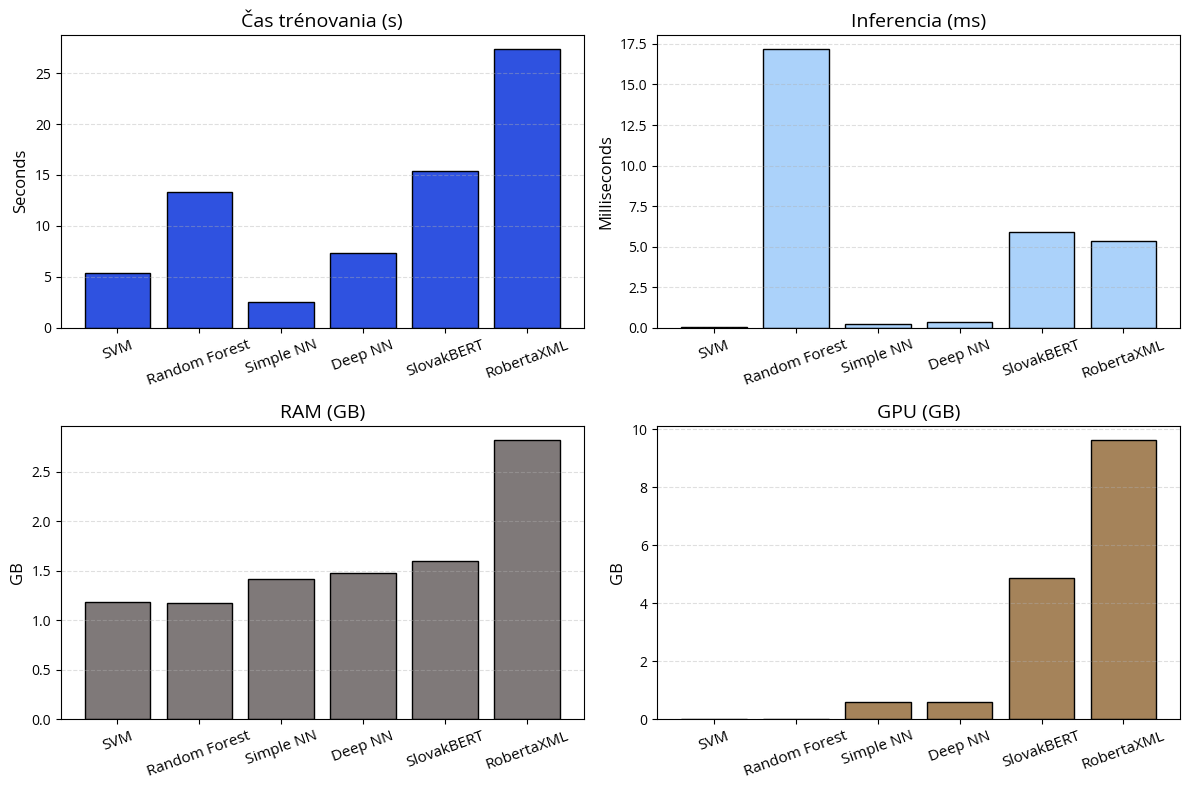

In [11]:
# Benchmarking results visualization
import matplotlib.font_manager as fm

# Font file
font_path ="/home/xkubanova_126831/bakalarka/font/Open_Sans/OpenSans-VariableFont_wdth,wght.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'Open Sans'

PRIMARY = '#2f52e0'
SECONDARY = '#abd2fa'
NEUTRAL = '#7f7979'
ACCENT = '#a5835a'

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

models = df_results.index.tolist()

# Training time
axes[0,0].bar(models, df_results['training_time_s'],
              color=PRIMARY,
              edgecolor='black')

axes[0,0].set_title('Čas trénovania (s)', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Seconds', fontsize=12)
axes[0,0].tick_params(axis='x', rotation=20, labelsize=11)
axes[0,0].grid(axis='y', linestyle='--', alpha=0.4)


# Inference time
axes[0,1].bar(models, df_results['latency_ms'],
              color=SECONDARY,
              edgecolor='black')

axes[0,1].set_title('Inferencia (ms)', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Milliseconds', fontsize=12)
axes[0,1].tick_params(axis='x', rotation=20, labelsize=11)
axes[0,1].grid(axis='y', linestyle='--', alpha=0.4)


# Peak RAM
axes[1,0].bar(models, df_results['peak_ram_gb'],
              color=NEUTRAL,
              edgecolor='black')

axes[1,0].set_title('RAM (GB)', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('GB', fontsize=12)
axes[1,0].tick_params(axis='x', rotation=20, labelsize=11)
axes[1,0].grid(axis='y', linestyle='--', alpha=0.4)


# Peak GPU
axes[1,1].bar(models, df_results['peak_gpu_gb'],
              color=ACCENT,
              edgecolor='black')

axes[1,1].set_title('GPU (GB)', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('GB', fontsize=12)
axes[1,1].tick_params(axis='x', rotation=20, labelsize=11)
axes[1,1].grid(axis='y', linestyle='--', alpha=0.4)


plt.tight_layout()

plt.savefig(
    'comparison_compute.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

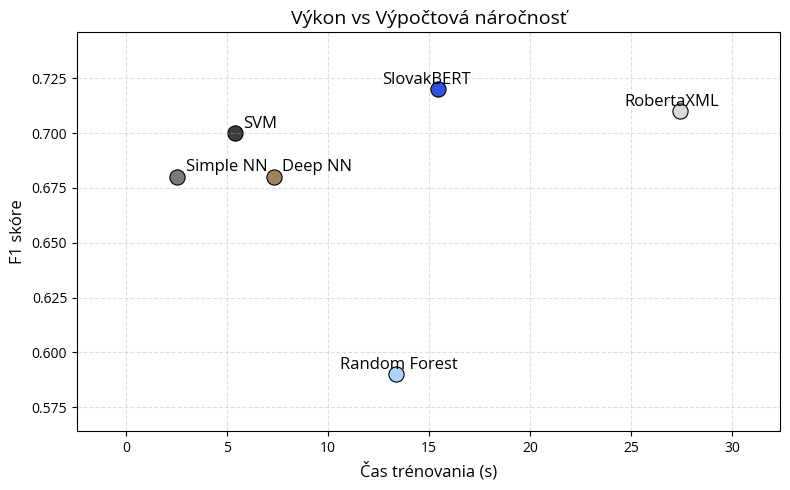

In [12]:
# F1 vs Training time chart
import matplotlib.font_manager as fm

# Font file
font_path ="/home/xkubanova_126831/bakalarka/font/Open_Sans/OpenSans-VariableFont_wdth,wght.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'Open Sans'


PRIMARY = '#2f52e0'
SECONDARY = '#abd2fa'
NEUTRAL = '#7f7979'
NEUTRAL_DARK = '#3d3b3c'
ACCENT = '#a5835a'
NEUTRAL_LIGHT = '#d9d9d9'

model_colors = {
    'SVM': NEUTRAL_DARK,
    'Random Forest': SECONDARY,
    'Simple NN': NEUTRAL,
    'Deep NN': ACCENT,
    'SlovakBERT': PRIMARY,
    'RobertaXML': NEUTRAL_LIGHT, 
}

fig, ax = plt.subplots(figsize=(8, 5))

for model_name, row in df_results.iterrows():
    if row['macro_f1'] is not None:

        x = row['training_time_s']
        y = row['macro_f1']

        color = model_colors.get(model_name, PRIMARY)

        ax.scatter(x, y, s=120, color=color,
                   edgecolor='black', linewidth=0.8)

       
        if x > df_results['training_time_s'].mean():
            offset = (-40, 4) 
        else:
            offset = (6, 4)    

        ax.annotate(
            model_name,
            (x, y),
            textcoords='offset points',
            xytext=offset,
            fontsize=12
        )

ax.set_xlabel('Čas trénovania (s)', fontsize=12)
ax.set_ylabel('F1 skóre', fontsize=12)

ax.set_title(
    'Výkon vs Výpočtová náročnosť',
    fontsize=14,
    fontweight='bold'
)

ax.grid(
    True,
    linestyle='--',
    alpha=0.4
)

ax.margins(x=0.2, y=0.2)
plt.tight_layout()

plt.savefig(
    'comparison_tradeoff.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


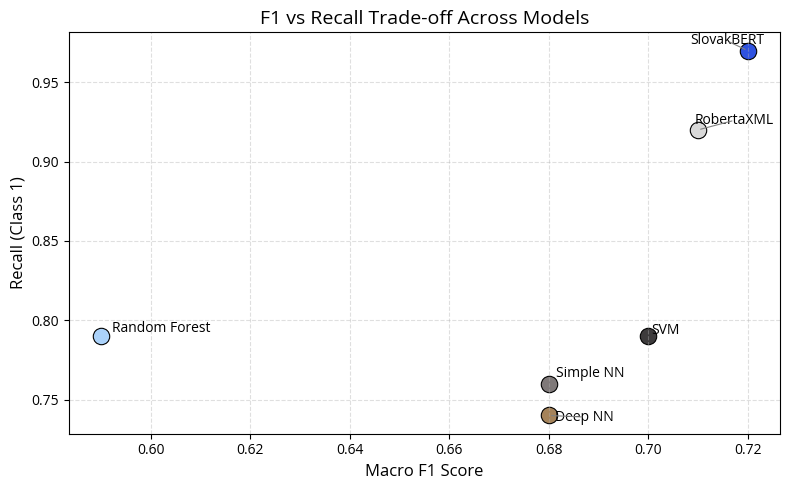

In [13]:
# F1 vs Recall chart
from adjustText import adjust_text
fig, ax = plt.subplots(figsize=(8, 5))

texts = []

for model_name, row in df_results.iterrows():

    if row['macro_f1'] is not None and row['recall_1'] is not None:

        x = row['macro_f1']
        y = row['recall_1']


        color = model_colors.get(model_name, PRIMARY)

        ax.scatter(
            x,
            y,
            s=140,
            color=color,
            edgecolor='black',
            linewidth=0.8
        )

       
        texts.append(
            ax.text(x, y, model_name, fontsize=10)
        )
        


adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.8),

    expand_points=(1.5, 2),   
    expand_text=(1.5, 2),    

    force_text=1,             
    force_points=1,          

    lim=500                   
)


ax.set_xlabel('Macro F1 Score', fontsize=12)
ax.set_ylabel('Recall (Class 1)', fontsize=12)


ax.set_title(
    'F1 vs Recall Trade-off Across Models',
    fontsize=14,
    fontweight='bold'
)


ax.grid(
    True,
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    'comparison_f1_vs_recall.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

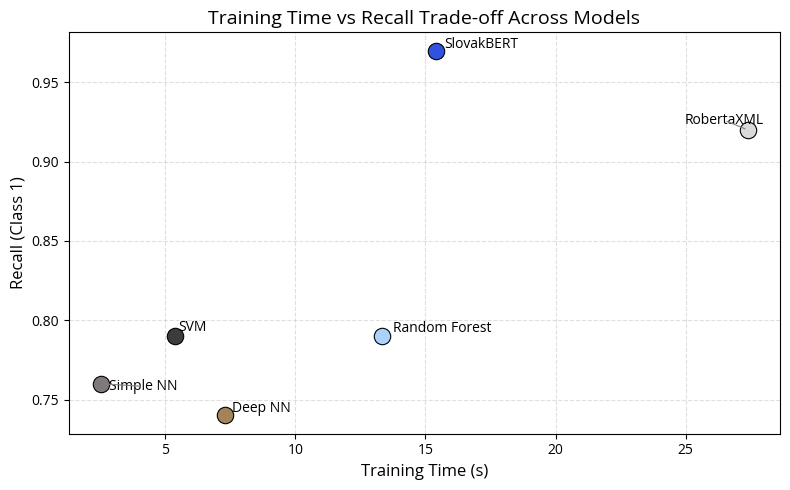

In [14]:
# Training time vs Recall chart
from adjustText import adjust_text
fig, ax = plt.subplots(figsize=(8, 5))

texts = []

for model_name, row in df_results.iterrows():

    if row['training_time_s'] is not None and row['recall_1'] is not None:

        x = row['training_time_s']
        y = row['recall_1']


        color = model_colors.get(model_name, PRIMARY)

        ax.scatter(
            x,
            y,
            s=140,
            color=color,
            edgecolor='black',
            linewidth=0.8
        )

       
        texts.append(
            ax.text(x, y, model_name, fontsize=10)
        )
        


adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.8),

    expand_points=(1.5, 2),   
    expand_text=(1.5, 2),     

    force_text=1,            
    force_points=1,           

    lim=500                    
)

# axis labels
ax.set_xlabel('Training Time (s)', fontsize=12)
ax.set_ylabel('Recall (Class 1)', fontsize=12)

# title
ax.set_title(
    'Training Time vs Recall Trade-off Across Models',
    fontsize=14,
    fontweight='bold'
)

# grid
ax.grid(
    True,
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    'comparison_training_time_vs_recall.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()